Dan Doan <br>
2/22/2026

In [1]:
#pd.set_option('display.max_rows', 250)
#pd.set_option('display.max_rows', 10)

In [2]:
import pandas as pd
import numpy as np

data = pd.read_csv("/Users/doan_/desktop/Jupyter Notebook/DSC680/daily_internet_usage_by_age_group.csv")
#data = pd.read_excel("/Users/doan_/desktop/Jupyter Notebook/DSC640/nationaldatabaseofchildcareprices.xlsx")

data

,user_id,date,age,age_group,social_media_hours,work_or_study_hours,entertainment_hours,total_screen_time,primary_device,internet_type
0,1,2024-04-02,15,13-18,2.2,3.7,2.4,8.3,Mobile,WiFi
1,2,2024-06-07,13,13-18,1.1,6.9,2.1,10.1,Tablet,WiFi
2,3,2024-04-03,21,19-25,1.3,5.7,1.6,8.6,Tablet,WiFi
3,4,2024-10-02,35,26-35,2.5,5.0,2.0,9.5,Mobile,WiFi
4,5,2024-10-05,49,46-60,0.2,6.3,2.8,9.3,Laptop,WiFi
...,...,...,...,...,...,...,...,...,...,...
2795,2796,2024-11-19,33,26-35,3.2,2.6,1.2,7.0,Mobile,Mobile Data
2796,2797,2024-06-24,52,46-60,2.1,1.2,3.0,6.3,Mobile,WiFi
2797,2798,2024-03-11,21,19-25,1.2,6.0,0.7,7.9,Mobile,Mobile Data
2798,2799,2024-12-30,20,19-25,2.2,6.4,1.6,10.2,Mobile,WiFi


In [3]:
# Returns True if any NA value exists, False otherwise
data['entertainment_hours'].isnull().any().any()

np.False_

In [4]:

age_median = data['age'].median()
#age_median # is 35
#data['age'] = data['age'].fillna(age_median)

#data

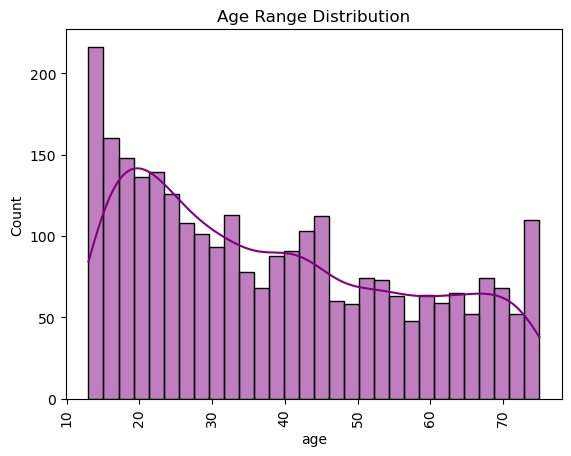

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data['age'], kde=True, bins=30, color='purple')

#plt.xlabel('County Name')
plt.title('Age Range Distribution')
plt.xticks(rotation='vertical')
plt.show()

In [17]:

#print(data['age'].value_counts())

#min(data['age'])

# Check if *any* value is NaN
print(np.isnan(data['age']).any())

False


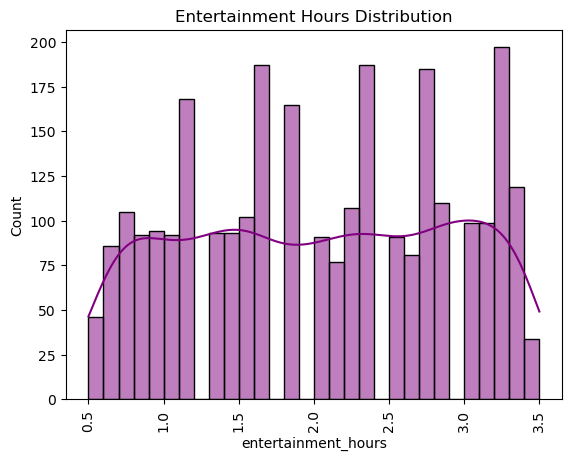

In [12]:
sns.histplot(data['entertainment_hours'], kde=True, bins=30, color='purple')

#plt.xlabel('County Name')
plt.title('Entertainment Hours Distribution')
plt.xticks(rotation='vertical')
plt.show()

In [11]:
# Step 2: Need to filter data set 

filtered_data_columns = data[['age', 'social_media_hours','work_or_study_hours', 'entertainment_hours', 'internet_type']]

filtered_data_columns

,age,social_media_hours,work_or_study_hours,entertainment_hours,internet_type
0,15,2.2,3.7,2.4,WiFi
1,13,1.1,6.9,2.1,WiFi
2,21,1.3,5.7,1.6,WiFi
3,35,2.5,5.0,2.0,WiFi
4,49,0.2,6.3,2.8,WiFi
...,...,...,...,...,...
2795,33,3.2,2.6,1.2,Mobile Data
2796,52,2.1,1.2,3.0,WiFi
2797,21,1.2,6.0,0.7,Mobile Data
2798,20,2.2,6.4,1.6,WiFi


In [18]:
filtered_data_columns_with_dummies = pd.get_dummies(filtered_data_columns, dtype=int) 

filtered_data_columns_with_dummies

,age,social_media_hours,work_or_study_hours,entertainment_hours,internet_type_Mobile Data,internet_type_WiFi
0,15,2.2,3.7,2.4,0,1
1,13,1.1,6.9,2.1,0,1
2,21,1.3,5.7,1.6,0,1
3,35,2.5,5.0,2.0,0,1
4,49,0.2,6.3,2.8,0,1
...,...,...,...,...,...,...
2795,33,3.2,2.6,1.2,1,0
2796,52,2.1,1.2,3.0,0,1
2797,21,1.2,6.0,0.7,1,0
2798,20,2.2,6.4,1.6,0,1


In [19]:
# 2) Apply a standard scalar to the data.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
filtered_data_columns_standardized = scaler.fit_transform(filtered_data_columns_with_dummies)
filtered_data_columns_standardized

array([[-1.2693086 ,  0.07439744, -0.18353696,  0.43160639, -0.99430195,
         0.99430195],
       [-1.3778081 , -0.91329274,  1.67443524,  0.08912635, -0.99430195,
         0.99430195],
       [-0.94381008, -0.73371271,  0.97769566, -0.48167371, -0.99430195,
         0.99430195],
       ...,
       [-0.94381008, -0.82350273,  1.15188056, -1.50911382,  1.00573071,
        -1.00573071],
       [-0.99805983,  0.07439744,  1.38412708, -0.48167371, -0.99430195,
         0.99430195],
       [ 0.79218202, -0.19497261, -0.82221491,  0.65992641, -0.99430195,
         0.99430195]], shape=(2800, 6))

C:\Users\doan_\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=11.
  warnings.warn(
C:\Users\doan_\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=11.
  warnings.warn(
C:\Users\doan_\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=11.
  warnings.warn(
C:\Users\doan_\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Win

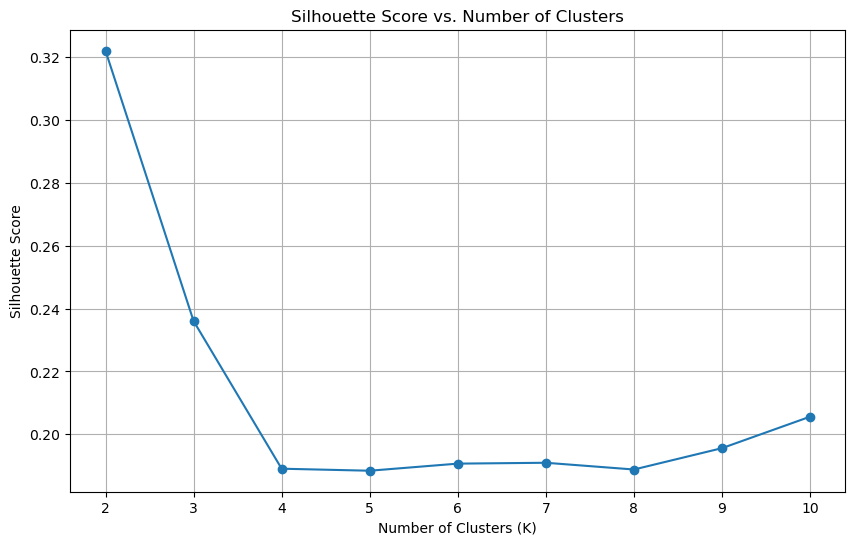

In [20]:
# 3) Create a plot of the cluster silhouette score versus the number of clusters in a K-means cluster.

import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Generate sample data (replace with your actual data)
######X = np.random.rand(100, 2)
X = filtered_data_columns_standardized

# Range of number of clusters to try
cluster_range = range(2, 11)

# Lists to store silhouette scores
silhouette_scores = []


# Calculate silhouette score for each number of clusters
for n_clusters in cluster_range:
    # Initialize KMeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
    
    # Fit KMeans and predict clusters
    cluster_labels = kmeans.fit_predict(X)
    
    # Calculate silhouette score
    silhouette_avg = silhouette_score(X, cluster_labels)
    silhouette_scores.append(silhouette_avg)

# Plot silhouette score vs. number of clusters
plt.figure(figsize=(10, 6))
plt.plot(cluster_range, silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs. Number of Clusters")
plt.xticks(cluster_range)
plt.grid(True)
plt.show()

In [21]:
# 5) Fit a K-means model to the data with the optimal number of clusters chosen in part (4).
 
# Use chosen k
#kmeans = KMeans(n_clusters=7, init='k-means++', max_iter=300, n_init=10, random_state=0) 
kmeans = KMeans(n_clusters=4, init='k-means++', max_iter=300, n_init=10, random_state=0) 
#kmeans = KMeans(n_clusters=9, init='k-means++', max_iter=2000, n_init=10, random_state=0) 
kmeans.fit(X)

C:\Users\doan_\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=11.
  warnings.warn(


,n_clusters,4
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


In [22]:
# 6) Fit a PCA transformation with two features to the scaled data.

from sklearn.decomposition import PCA


# Apply PCA with 2 components
pca = PCA(n_components=2) 
pca.fit(X)

# Transform the data
pca_data = pca.transform(X)

C:\Users\doan_\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=11.
  warnings.warn(


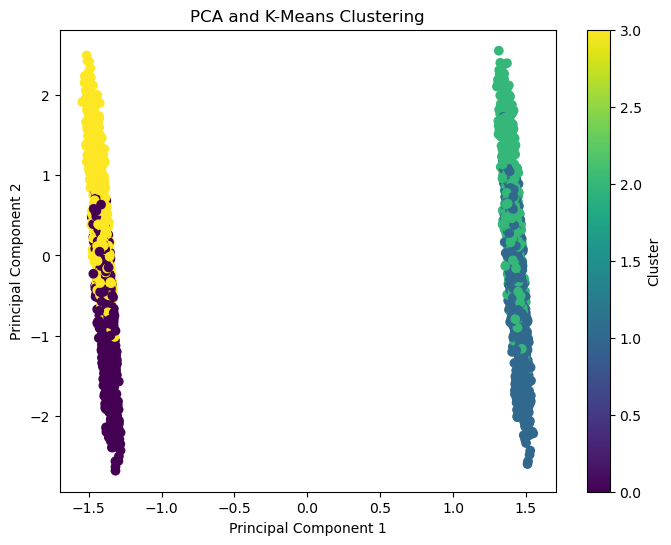

In [23]:
# 7) Make a scatterplot the PCA transformed data coloring each point by its cluster value.


# Visualize 
plt.figure(figsize=(8, 6))
plt.scatter(pca_data[:,0], pca_data[:,1], c=kmeans.fit(X).labels_.astype(float))
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA and K-Means Clustering')
# Add a colorbar
plt.colorbar(label='Cluster') 

In [43]:
filtered_data_columns_2 = data[['age', 'social_media_hours','work_or_study_hours', 'entertainment_hours']]
#filtered_data_columns_2 = data[['age', 'social_media_hours','work_or_study_hours', 'internet_type']]

filtered_data_columns_2

,age,social_media_hours,work_or_study_hours,entertainment_hours
0,15,2.2,3.7,2.4
1,13,1.1,6.9,2.1
2,21,1.3,5.7,1.6
3,35,2.5,5.0,2.0
4,49,0.2,6.3,2.8
...,...,...,...,...
2795,33,3.2,2.6,1.2
2796,52,2.1,1.2,3.0
2797,21,1.2,6.0,0.7
2798,20,2.2,6.4,1.6


In [44]:
filtered_data_columns_with_dummies_2 = pd.get_dummies(filtered_data_columns_2, dtype=int) 

filtered_data_columns_with_dummies_2

,age,social_media_hours,work_or_study_hours,entertainment_hours
0,15,2.2,3.7,2.4
1,13,1.1,6.9,2.1
2,21,1.3,5.7,1.6
3,35,2.5,5.0,2.0
4,49,0.2,6.3,2.8
...,...,...,...,...
2795,33,3.2,2.6,1.2
2796,52,2.1,1.2,3.0
2797,21,1.2,6.0,0.7
2798,20,2.2,6.4,1.6


In [45]:
scaler_2 = StandardScaler()
filtered_data_columns_standardized_2 = scaler_2.fit_transform(filtered_data_columns_with_dummies_2)
filtered_data_columns_standardized_2

array([[-1.2693086 ,  0.07439744, -0.18353696,  0.43160639],
       [-1.3778081 , -0.91329274,  1.67443524,  0.08912635],
       [-0.94381008, -0.73371271,  0.97769566, -0.48167371],
       ...,
       [-0.94381008, -0.82350273,  1.15188056, -1.50911382],
       [-0.99805983,  0.07439744,  1.38412708, -0.48167371],
       [ 0.79218202, -0.19497261, -0.82221491,  0.65992641]],
      shape=(2800, 4))

C:\Users\doan_\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=11.
  warnings.warn(
C:\Users\doan_\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=11.
  warnings.warn(
C:\Users\doan_\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=11.
  warnings.warn(
C:\Users\doan_\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Win

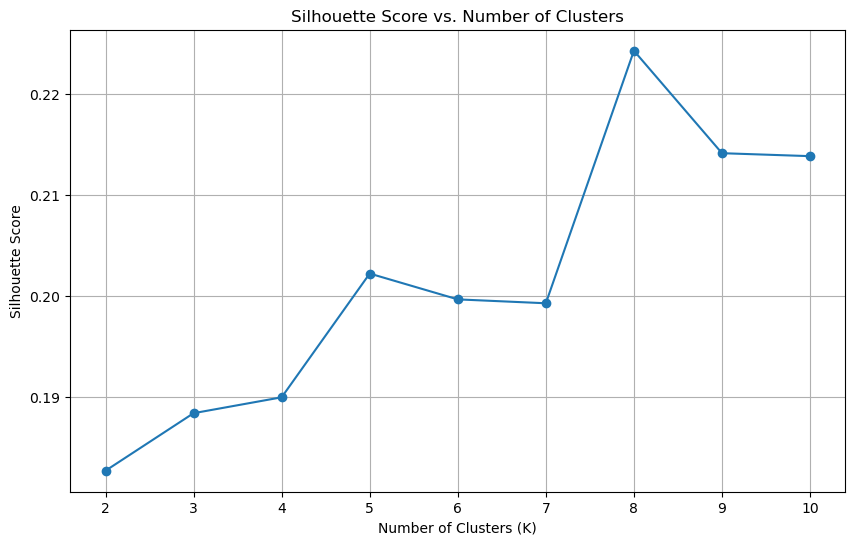

In [46]:
# Generate sample data (replace with your actual data)
######X = np.random.rand(100, 2)
X_2 = filtered_data_columns_standardized_2

# Range of number of clusters to try
cluster_range_2 = range(2, 11)

# Lists to store silhouette scores
silhouette_scores_2 = []


# Calculate silhouette score for each number of clusters
for n_clusters in cluster_range_2:
    # Initialize KMeans
    kmeans_2 = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
    
    # Fit KMeans and predict clusters
    cluster_labels_2 = kmeans_2.fit_predict(X_2)
    
    # Calculate silhouette score
    silhouette_avg_2 = silhouette_score(X_2, cluster_labels_2)
    silhouette_scores_2.append(silhouette_avg_2)

# Plot silhouette score vs. number of clusters
plt.figure(figsize=(10, 6))
plt.plot(cluster_range_2, silhouette_scores_2, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs. Number of Clusters")
plt.xticks(cluster_range_2)
plt.grid(True)
plt.show()

In [53]:
# Use chosen k
#kmeans = KMeans(n_clusters=7, init='k-means++', max_iter=300, n_init=10, random_state=0) 
kmeans_2 = KMeans(n_clusters=4, init='k-means++', max_iter=300, n_init=10, random_state=0) 
#kmeans_2 = KMeans(n_clusters=6, init='k-means++', max_iter=300, n_init=10, random_state=0) 
kmeans_2.fit(X_2)

C:\Users\doan_\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=11.
  warnings.warn(


,n_clusters,4
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


In [54]:
pca_2 = PCA(n_components=2) 
pca_2.fit(X_2)

# Transform the data
pca_data_2 = pca_2.transform(X_2)

C:\Users\doan_\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=11.
  warnings.warn(


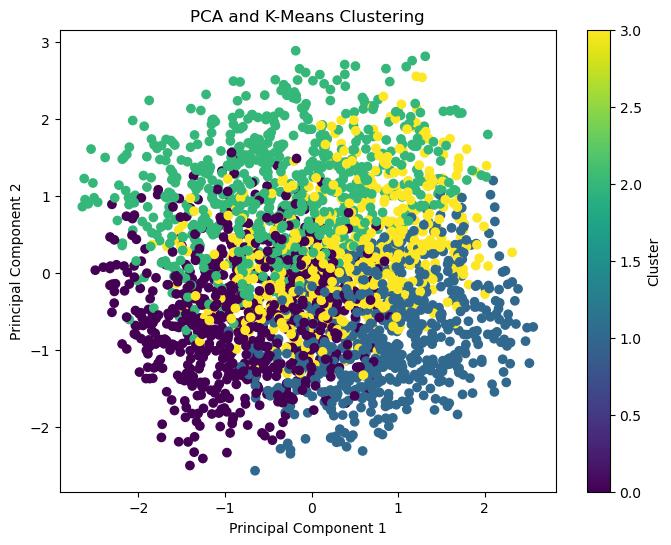

In [55]:
plt.figure(figsize=(8, 6))
plt.scatter(pca_data_2[:,0], pca_data_2[:,1], c=kmeans_2.fit(X_2).labels_.astype(float))
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA and K-Means Clustering')
# Add a colorbar
plt.colorbar(label='Cluster') 

In [57]:
filtered_data_columns_with_dummies_2['entertainment_hours']

0       2.4
1       2.1
2       1.6
3       2.0
4       2.8
       ... 
2795    1.2
2796    3.0
2797    0.7
2798    1.6
2799    2.6
Name: entertainment_hours, Length: 2800, dtype: float64

In [59]:
from sklearn.model_selection import train_test_split

filtered_data_columns_with_dummies_2_filter = filtered_data_columns_with_dummies_2.drop(['entertainment_hours'], axis=1)

filtered_data_columns_with_dummies_2_filter

,age,social_media_hours,work_or_study_hours
0,15,2.2,3.7
1,13,1.1,6.9
2,21,1.3,5.7
3,35,2.5,5.0
4,49,0.2,6.3
...,...,...,...
2795,33,3.2,2.6
2796,52,2.1,1.2
2797,21,1.2,6.0
2798,20,2.2,6.4


In [60]:
# target == Y (dependent variable)
# how to manually split the two accordingly 
features_train, features_test, target_train, target_test = train_test_split(filtered_data_columns_with_dummies_2_filter, filtered_data_columns_with_dummies_2['entertainment_hours'], test_size=0.2, random_state=0)


In [61]:
from sklearn.linear_model import LinearRegression

# initalize the LinearRegression model
regression = LinearRegression()

# fit the training dataset to the linear regression model
model = regression.fit(features_train, target_train)


print(model.score(features_train, target_train))

0.0019190539196072276


In [62]:
from sklearn.metrics import mean_absolute_error

target_test_prediction = model.predict(features_test)

In [63]:
from sklearn.metrics import mean_absolute_error

target_test_prediction = model.predict(features_test)

from sklearn.metrics import r2_score, mean_squared_error


rmse_test = np.sqrt(mean_squared_error(target_test, target_test_prediction))

r2_test = r2_score(target_test, target_test_prediction)

print("Testing R²:", r2_test) # higher means better fit
print("Testing RMSE:", rmse_test) # # lower means better fit 

Testing R²: -0.0030962598162451727
Testing RMSE: 0.8751774929136074
